# **Lab5.1 : CNN Feature maps**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

## Get VGG16 Pretrained model
Explore the VGG16 achitecture.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (18): ReLU(inplace=True)
    (19): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (20): ReLU(inplace=True)
    (21): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (22): ReLU(inplace=True)
    (23): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (24): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (25): ReLU(inplace=True)
    (26): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (27): ReLU(inplace=True)
    (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (29): ReLU(inplace=True)
    (30): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0): Linear(in_features=25088, out_features=4096, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=4096, out_features=4096, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=4096, out_features=1000, bias=True)
  )
)
```

</details>


In [2]:
### START CODE HERE ###

vgg16 = models.vgg16(pretrained=True)

print(vgg16)

### END CODE HERE ###

/home/phuwit/Programming/KMITL-ImageProcessing/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/phuwit/Programming/KMITL-ImageProcessing/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/phuwit/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 111MB/s]  


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Explore all layers in feature extractor part.
[Read more.](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.named_modules:~:text=named_modules(memo%3DNone%2C%20prefix%3D%27%27%2C%20remove_duplicate%3DTrue))


<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
-------------------
0:Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
1:ReLU(inplace=True)
-------------------
2:Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
3:ReLU(inplace=True)
-------------------
4:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
...
28:Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
29:ReLU(inplace=True)
-------------------
30:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
```

</details>


In [ ]:
### START CODE HERE ###

# วน loop แสดงเฉพาะ features (Conv / ReLU / Pooling) ทีละ layer
for idx, layer in enumerate(vgg16.features): # type: ignore
    print(f"{idx}:{layer}")
    print("-------------------")

### END CODE HERE ###

0:Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
1:ReLU(inplace=True)
-------------------
2:Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
3:ReLU(inplace=True)
-------------------
4:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
-------------------
5:Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
6:ReLU(inplace=True)
-------------------
7:Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
8:ReLU(inplace=True)
-------------------
9:MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
-------------------
10:Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
11:ReLU(inplace=True)
-------------------
12:Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
-------------------
13:ReLU(inplace=True)
-------------------
14:Conv2d(256, 256, ke

Examine weight and bias of first Convolution layer and ReLU layer. [Read more.](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html)
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
torch.Size([64, 3, 3, 3])
Kernel : 0
*************************************
Channel : 0
[[-0.5537306   0.1427047   0.5289615 ]
 [-0.58312404  0.35655147  0.76566225]
 [-0.69022113 -0.04801885  0.48409155]]
Min coefficients -0.69022113
-------------------------------------
Channel : 1
[[ 0.17548391  0.00986297 -0.08141315]
 [ 0.04408892 -0.07032251 -0.26035076]
 [ 0.13239175 -0.1727862  -0.1322633 ]]
Min coefficients -0.26035076
-------------------------------------
Channel : 2
[[ 0.31302562 -0.1659134  -0.42752257]
 [ 0.47518674 -0.08267727 -0.48699915]
 [ 0.63202524  0.01930757 -0.2775303 ]]
Min coefficients -0.48699915
-------------------------------------


Kernel : 1
*************************************
Channel : 0
[[ 0.23253721  0.12665984  0.1860546 ]
 [-0.42805314 -0.24348575  0.24628444]
 [-0.2506616   0.14177004 -0.0054864 ]]
Min coefficients -0.42805314
-------------------------------------
Channel : 1
[[-0.14076217 -0.21902554  0.15040672]
 [-0.84126675 -0.3517562   0.5639763 ]
 [-0.24194452  0.5192758   0.5391499 ]]
Min coefficients -0.84126675
-------------------------------------
Channel : 2
[[-0.31432396 -0.37047786 -0.13093661]
 [-0.47144184 -0.15503426  0.3458899 ]
 [ 0.05438393  0.5868277   0.49579924]]
Min coefficients -0.47144184
-------------------------------------

...
```

</details>

In [4]:
### START CODE HERE ###

# ดึง conv และ relu แรก
first_conv = vgg16.features[0] # type: ignore
first_relu = vgg16.features[1] # type: ignore

# ดึง weight ของ conv แรก
weights = first_conv.weight.data
print(weights.shape)   # torch.Size([64, 3, 3, 3])

# วนลูปดู filter ทีละ kernel
for kernel_idx in range(2):  # ตัวอย่างแสดงแค่ 2 kernels แรก
    print(f"Kernel : {kernel_idx}")
    print("*************************************")
    for channel_idx in range(weights.shape[1]):
        channel_weights = weights[kernel_idx, channel_idx, :, :].numpy()
        print(f"Channel : {channel_idx}")
        print(channel_weights)
        print("Min coefficients", channel_weights.min())
        print("-------------------------------------")

### END CODE HERE ###

torch.Size([64, 3, 3, 3])
Kernel : 0
*************************************
Channel : 0
[[-0.5537306   0.1427047   0.5289615 ]
 [-0.58312404  0.35655147  0.76566225]
 [-0.69022113 -0.04801885  0.48409155]]
Min coefficients -0.69022113
-------------------------------------
Channel : 1
[[ 0.17548391  0.00986297 -0.08141315]
 [ 0.04408892 -0.07032251 -0.26035076]
 [ 0.13239175 -0.1727862  -0.1322633 ]]
Min coefficients -0.26035076
-------------------------------------
Channel : 2
[[ 0.31302562 -0.1659134  -0.42752257]
 [ 0.47518674 -0.08267727 -0.48699915]
 [ 0.63202524  0.01930757 -0.2775303 ]]
Min coefficients -0.48699915
-------------------------------------
Kernel : 1
*************************************
Channel : 0
[[ 0.23253721  0.12665984  0.1860546 ]
 [-0.42805314 -0.24348575  0.24628444]
 [-0.2506616   0.14177004 -0.0054864 ]]
Min coefficients -0.42805314
-------------------------------------
Channel : 1
[[-0.14076217 -0.21902554  0.15040672]
 [-0.84126675 -0.3517562   0.5639763 

In [5]:
assert isinstance(first_conv, nn.Conv2d), "First layer should be a convolutional layer"
assert isinstance(first_relu, nn.ReLU), "Second layer should be a ReLU activation"
assert first_conv.weight.shape == (64, 3, 3, 3), "First layer weight shape should be (64, 3, 3, 3)"

Examine Biases
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

```
Bias : Parameter containing:
tensor([ 0.4034,  0.3778,  0.4644, -0.3228,  0.3940, -0.3953,  0.3951, -0.5496,
         ...
         0.2300,  0.4979,  0.5553,  0.5230, -0.2182,  0.0117, -0.5516,  0.2108],
       requires_grad=True)
```

</details>

In [6]:
### START CODE HERE ###

print("Bias :", first_conv.bias)

### END CODE HERE ###

Bias : Parameter containing:
tensor([ 0.4034,  0.3778,  0.4644, -0.3228,  0.3940, -0.3953,  0.3951, -0.5496,
         0.2693, -0.7602, -0.3508,  0.2334, -1.3239, -0.1694,  0.3938, -0.1026,
         0.0460, -0.6995,  0.1549,  0.5628,  0.3011,  0.3425,  0.1073,  0.4651,
         0.1295,  0.0788, -0.0492, -0.5638,  0.1465, -0.3890, -0.0715,  0.0649,
         0.2768,  0.3279,  0.5682, -1.2640, -0.8368, -0.9485,  0.1358,  0.2727,
         0.1841, -0.5325,  0.3507, -0.0827, -1.0248, -0.6912, -0.7711,  0.2612,
         0.4033, -0.4802, -0.3066,  0.5807, -1.3325,  0.4844, -0.8160,  0.2386,
         0.2300,  0.4979,  0.5553,  0.5230, -0.2182,  0.0117, -0.5516,  0.2108],
       requires_grad=True)


## Process the feature maps
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/1.png?raw=true)

</details>

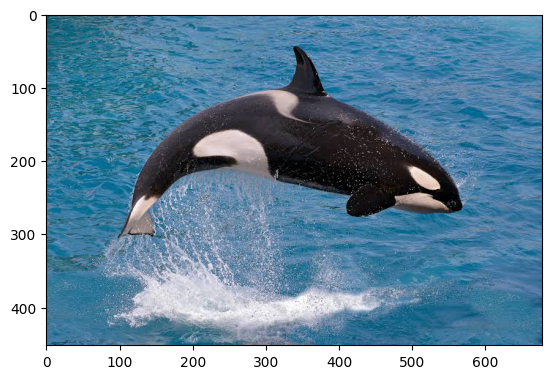

In [34]:
### START CODE HERE ###

import matplotlib.pyplot as plt
from PIL import Image

img_path = "assets/orca.png"
img = Image.open(img_path).convert("RGB")

plt.imshow(img)
plt.show()

### END CODE HERE ###

Normalize the image using the mean and standard deviation values from the [VGG16 normalization parameters.](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html)
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/2.png?raw=true)

</details>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


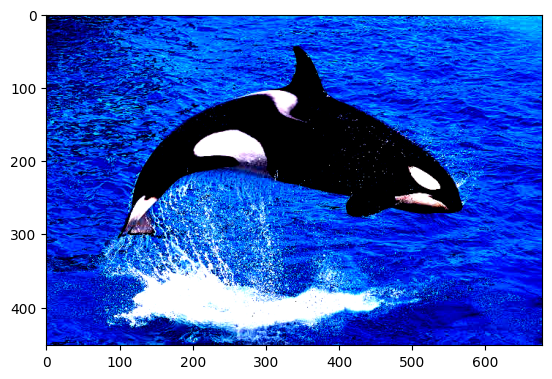

In [35]:
### START CODE HERE ###

# แปลงเป็น Tensor และ Normalize ด้วย mean, std ของ VGG16
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

img_tensor = transform(img)

# แปลงกลับมาเป็น numpy image เพื่อนำมาแสดงผล
def denormalize(tensor, mean, std):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

img_denorm = denormalize(img_tensor, [0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])

# แสดงผล
plt.imshow(img_tensor.permute(1, 2, 0).numpy()) # type: ignore
# plt.imshow(img_denorm.permute(1, 2, 0).numpy())
plt.show()

### END CODE HERE ###

Convert the [NumPy image to a PyTorch tensor](https://pytorch.org/docs/stable/torch.html#:~:text=memory%2Dmapped%20file.-,from_numpy,-Creates%20a%20Tensor), ensuring it has the [correct dimensions and data type](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html) for input to the first convolution layer.

In [36]:
### START CODE HERE ###

print("Tensor shape:", img_tensor.shape) # type: ignore
print("Tensor dtype:", img_tensor.dtype) # type: ignore

# โหลดรูปด้วย OpenCV (BGR)
img = cv2.imread("assets/orca.png")
# แปลง BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # type: ignore

# resize ให้ตรงกับ VGG16 (224x224)
img = cv2.resize(img, (224, 224))

# แปลงจาก NumPy (H, W, C) -> Tensor (C, H, W)
img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()

# normalize ให้อยู่ในช่วง [0,1]
img_tensor = img_tensor / 255.0

# เพิ่ม batch dimension (N, C, H, W)
img_tensor = img_tensor.unsqueeze(0)

print("\nAfter resize")
print("Tensor shape:", img_tensor.shape)
print("Tensor dtype:", img_tensor.dtype)

### END CODE HERE ###

Tensor shape: torch.Size([3, 452, 678])
Tensor dtype: torch.float32

After resize
Tensor shape: torch.Size([1, 3, 224, 224])
Tensor dtype: torch.float32


Complete the function below. <br>
The plot_featuremap function takes a set of feature maps and creates a grid of subplots, each displaying a single feature map. 

In [12]:
### START CODE HERE ###

import math

def plot_featuremap(feature_maps, title="Feature Maps"):
    num_featuremaps = feature_maps.shape[1]   # จำนวน channels
    cols = 8
    rows = math.ceil(num_featuremaps / cols)

    plt.figure(figsize=(20, 20))
    for i in range(num_featuremaps):
        plt.subplot(rows, cols, i+1)
        plt.imshow(feature_maps[0, i].detach().cpu().numpy(), cmap='gray')
        plt.title(str(i+1), fontsize=15)   # เพิ่มเลข index
        plt.axis("off")
    plt.suptitle(title, fontsize=20)
    plt.show()

### END CODE HERE ###

Pass the image to the first convolutional layer and display the feature map output using your `plot_featuremap()` function.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/3.png?raw=true)
</details>

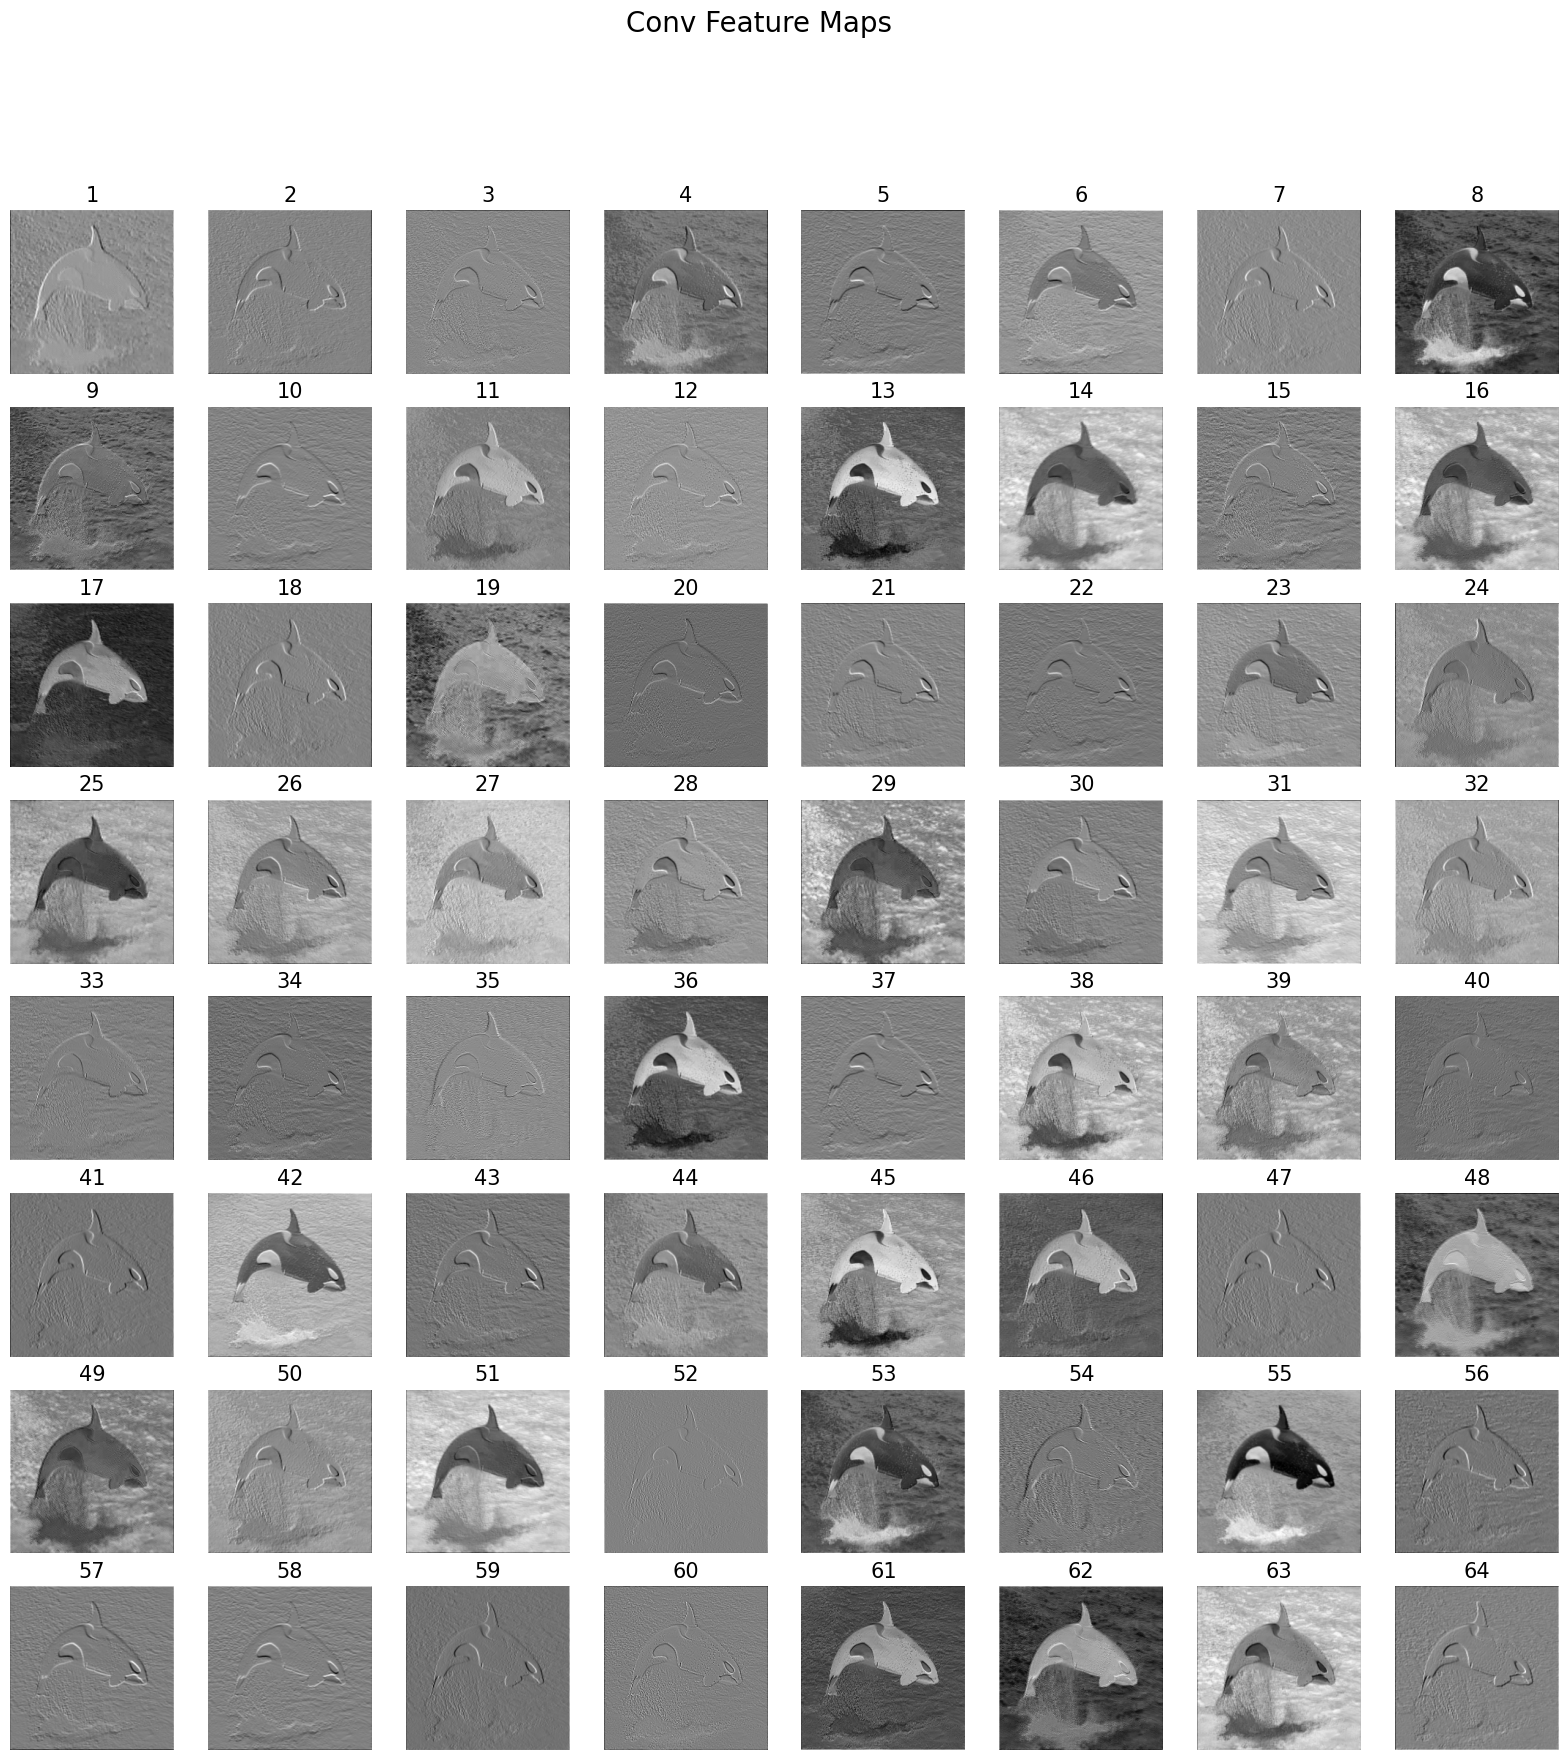

In [14]:
### START CODE HERE ###

# --- ส่งเข้า first conv layer ---
with torch.no_grad():
    feature_maps = first_conv(img_tensor)

# --- แสดงผล feature maps ---
plot_featuremap(feature_maps, title="Conv Feature Maps")

### END CODE HERE ###

Pass the image to the first ReLU layer and display the feature map output using your `plot_featuremap()` function.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/4.png?raw=true)

</details>

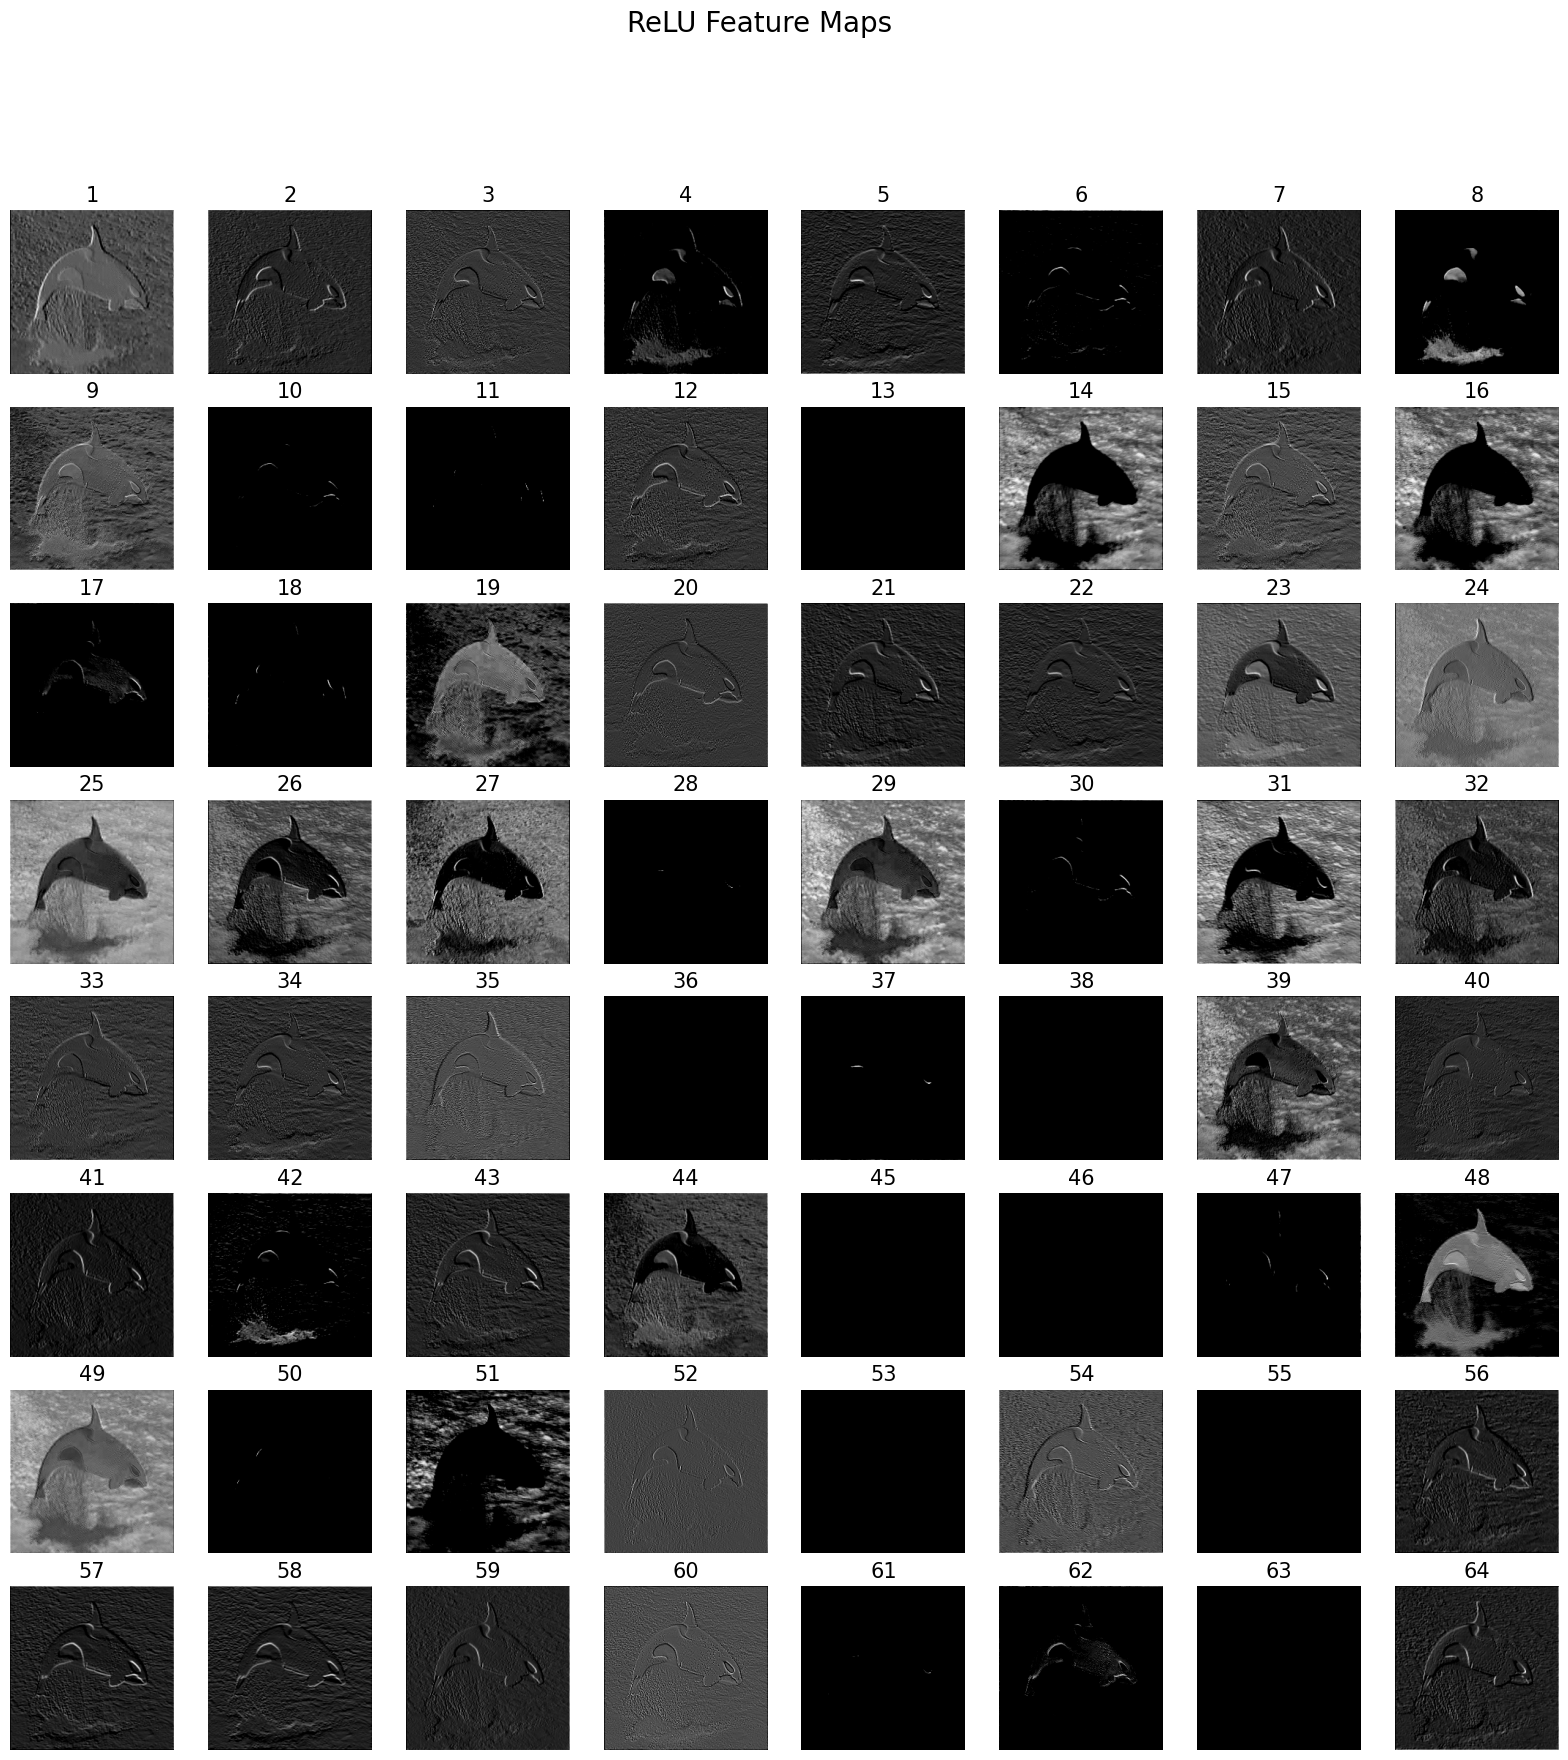

In [15]:
### START CODE HERE ###

# --- ส่งผ่าน Conv + ReLU ---
with torch.no_grad():
    conv_out = first_conv(img_tensor)
    relu_out = first_relu(conv_out)

# --- แสดงผล Feature maps ---
plot_featuremap(relu_out, title="ReLU Feature Maps")

### END CODE HERE ###

## Convolution 2D from scratch
Complete the function below

In [16]:
### START CODE HERE ###

def convolution2d(img, kernel, bias=0, padding=0, stride=1):
    """
    img: 2D numpy array (H, W)
    kernel: 2D numpy array (kH, kW)
    bias: scalar
    padding: int
    stride: int
    return: output feature map (2D numpy array)
    """
    # Padding
    if padding > 0:
        img_padded = np.pad(img, ((padding, padding), (padding, padding)), mode='constant')
    else:
        img_padded = img

    kH, kW = kernel.shape
    H, W = img_padded.shape

    # ขนาด output
    out_H = (H - kH)//stride + 1
    out_W = (W - kW)//stride + 1

    output = np.zeros((out_H, out_W))

    # convolution loop
    for i in range(0, out_H):
        for j in range(0, out_W):
            region = img_padded[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel) + bias

    return output

### END CODE HERE ###

Copy the weights and biases from `vgg16` and then use each kernel perform a 2D convolution using `convolution2d` and display the resulting feature map
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/5.png?raw=true)

</details>

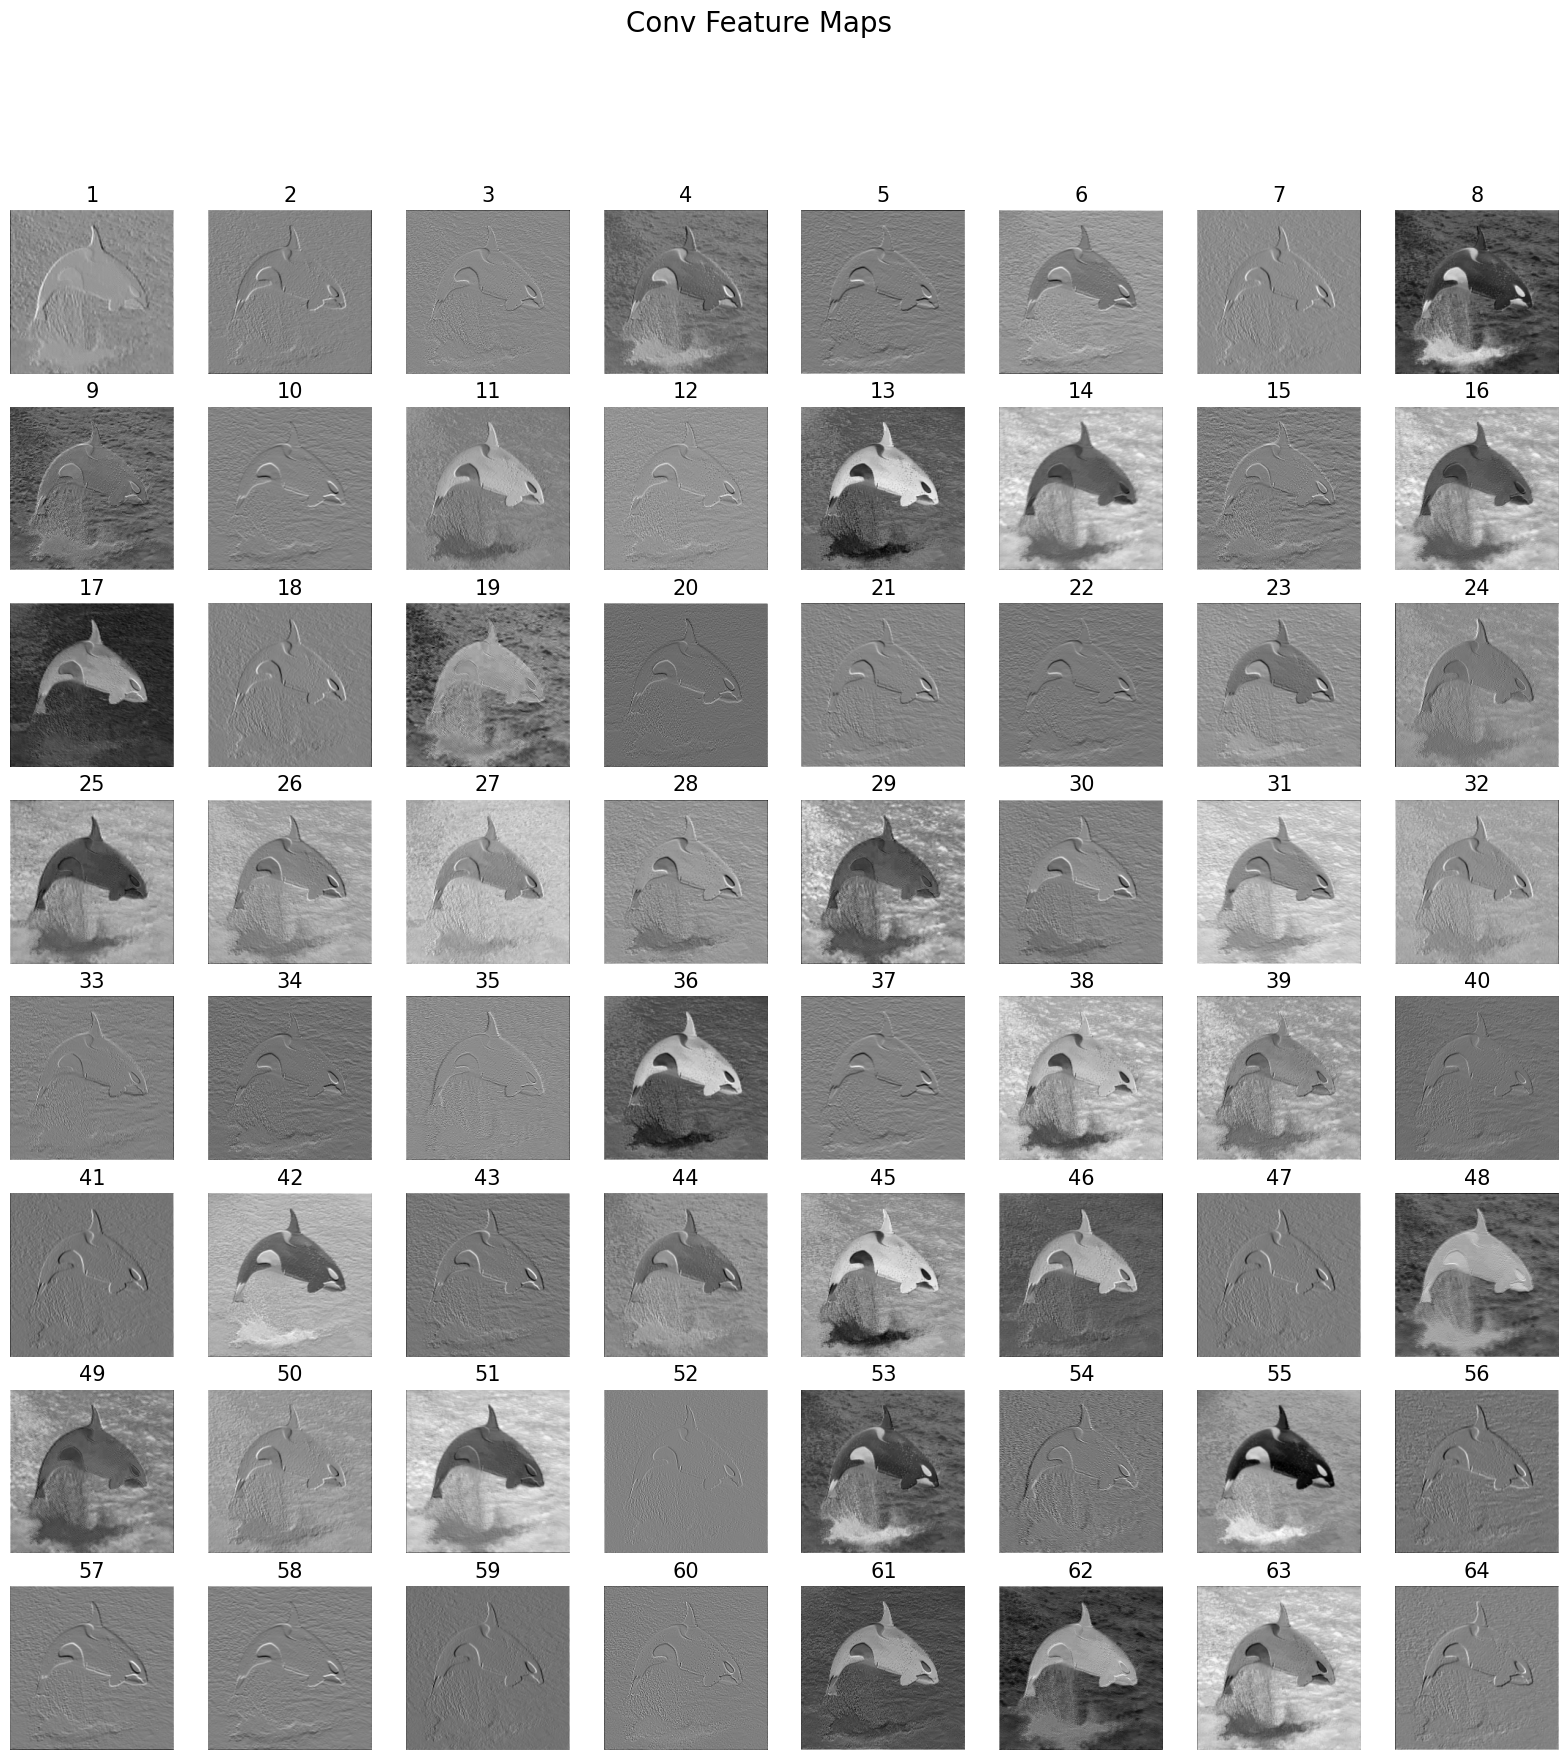

In [17]:
### START CODE HERE ###

# แปลงภาพเป็น NumPy
img_np = img_tensor[0].permute(1,2,0).numpy()  # (H, W, C)

# ดึง weights และ bias ของ Conv2d แรก
weights = first_conv.weight.data.numpy()  # shape: [64, 3, 3, 3]
biases  = first_conv.bias.data.numpy()    # shape: [64]

num_kernels = weights.shape[0]  # 64
feature_maps_all = []

# คำนวณ feature map ของแต่ละ kernel
for k in range(num_kernels):
    feature_map = np.zeros((224,224))
    for c in range(weights.shape[1]):  # 3 channels
        feature_map += convolution2d(img_np[:,:,c], weights[k,c], bias=biases[k], padding=1, stride=1)
    feature_maps_all.append(feature_map)

# แสดงผลทั้งหมดใน grid
cols = 8
rows = math.ceil(num_kernels / cols)
plt.figure(figsize=(20,20))

for i, fmap in enumerate(feature_maps_all):
    plt.subplot(rows, cols, i+1)
    plt.imshow(fmap, cmap='gray')
    plt.title(str(i+1), fontsize=15)  # index กำกับ
    plt.axis('off')

plt.suptitle("Conv Feature Maps", fontsize=20)
plt.show()

### END CODE HERE ###

After performing the `convolution2d` operation, apply the ReLU activation function to the output. Then, display the resulting feature map.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab5_CNN/assets/6.png?raw=true)

</details>

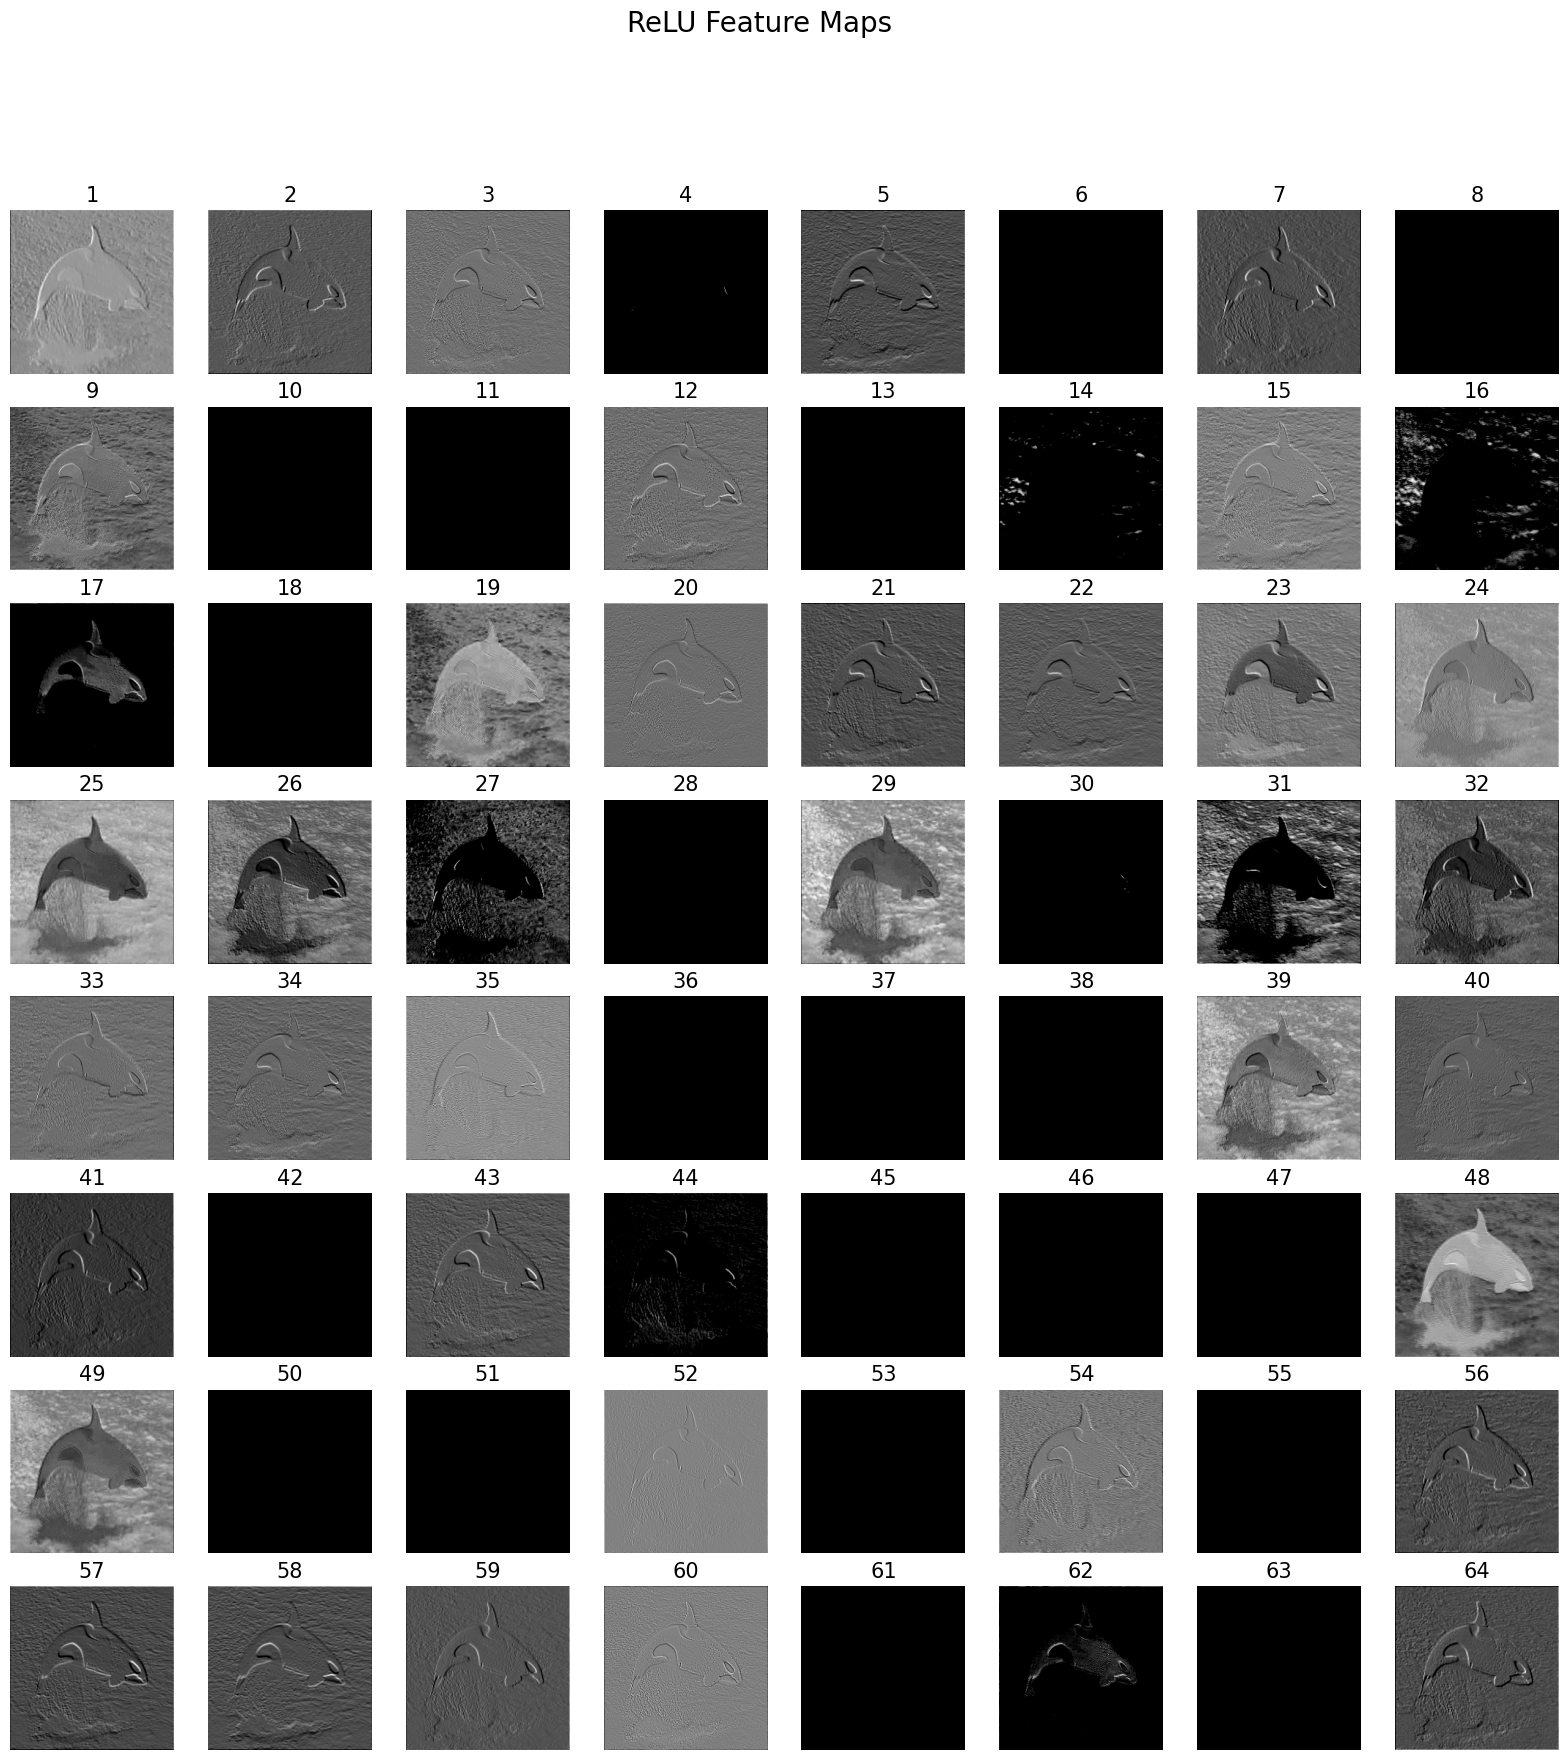

In [19]:
### START CODE HERE ###

# คำนวณ feature maps และ apply ReLU
num_kernels = weights.shape[0]  # 64
feature_maps_all = []

for k in range(num_kernels):
    feature_map = np.zeros((224,224))
    for c in range(weights.shape[1]):  # 3 channels
        feature_map += convolution2d(img_np[:,:,c], weights[k,c], bias=biases[k], padding=1, stride=1)
    # Apply ReLU
    feature_map = np.maximum(0, feature_map)
    feature_maps_all.append(feature_map)

# แสดงผลทั้งหมดใน grid
cols = 8
rows = math.ceil(num_kernels / cols)
plt.figure(figsize=(20,20))

for i, fmap in enumerate(feature_maps_all):
    plt.subplot(rows, cols, i+1)
    plt.imshow(fmap, cmap='gray')
    plt.title(str(i+1), fontsize=15)
    plt.axis('off')

plt.suptitle("ReLU Feature Maps", fontsize=20)
plt.show()

### END CODE HERE ###

---

# Question

1. Show the array of kernel weights used for extracting object color 
and those used for extracting object edge details at least two CNN nodes.
Compare and Discuss how the specific values of these kernel weights influence the CNN's ability 
to detect colors versus edges in images.

    color kernels have more gradual changes in weight from one cell to the next, edge kernel on the otherhand, have pronouncecd "edge" as seen in the demo below. 

2. Why is Matplotlib able to display the output feature map from the convolution layer, even though it contains negative values?

    matplotlib automatically normalize the data range

3. Is there a method faster than traditional 2D convolution in the "Convolution 2D from scratch" section?

    วิธีที่ทำได้เร็วกว่ามีหลายเทคนิค เช่น
    - FFT Convolution ใช้หลักการแปลงการคูณแบบ convolution ให้เป็นการคูณเชิงจุดใน domain ของความถี่ ทำให้การคำนวณเร็วขึ้นมากเมื่อ kernel มีขนาดใหญ่
    - Separable Convolution เช่น Depthwise Separable Convolution ที่ใช้ใน MobileNet แยก convolution ออกเป็นการคำนวณตามแกนแนวตั้งและแนวนอน เพื่อลดจำนวนการคำนวณ

torch.Size([64, 3, 3, 3])


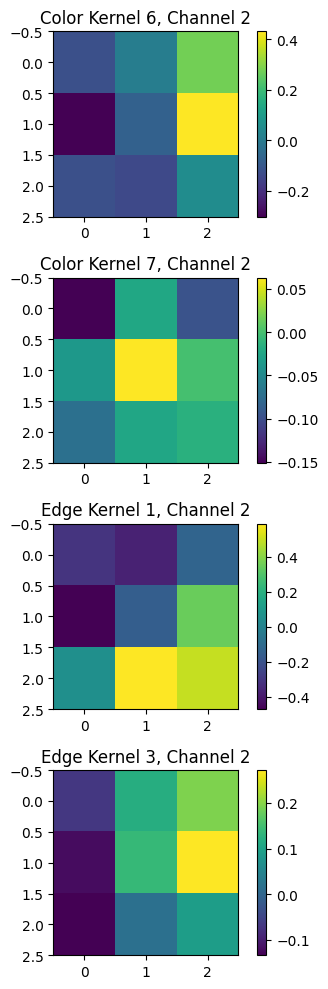

Color Detection Kernels:
Kernel : 6
*************************************
Channel : 2 (B)
[[-0.12294806  0.00894238  0.27380922]
 [-0.30174658 -0.07338092  0.43106747]
 [-0.12203427 -0.13931857  0.05425713]]
Min: -0.3017, Max: 0.4311
-------------------------------------


Kernel : 7
*************************************
Channel : 2 (B)
[[-0.15091112 -0.02322952 -0.09642062]
 [-0.03646013  0.06301151  0.00032308]
 [-0.07180016 -0.02415444 -0.01532429]]
Min: -0.1509, Max: 0.0630
-------------------------------------


Edge Detection Kernels:
Kernel : 1
*************************************
Channel : 2 (B)
[[-0.31432396 -0.37047786 -0.13093661]
 [-0.47144184 -0.15503426  0.3458899 ]
 [ 0.05438393  0.5868277   0.49579924]]
Min: -0.4714, Max: 0.5868
-------------------------------------


Kernel : 3
*************************************
Channel : 2 (B)
[[-0.06784473  0.11861335  0.19436684]
 [-0.12034615  0.13880135  0.27212286]
 [-0.13372129  0.01615521  0.092627  ]]
Min: -0.1337, Max: 0.

In [9]:
# q1

conv_colors_kernel_indexes = [6, 7]
conv_edge_kernel_indexes = [1, 3]

channel_idx = 2

first_conv = vgg16.features[0] # type: ignore

# ดึง weight ของ conv แรก
weights = first_conv.weight.data
print(weights.shape)   # torch.Size([64, 3, 3, 3])

# Plot the kernels for better visualization
plt.figure(figsize=(12, 10))

# Show color detection kernels
for i, kernel_idx in enumerate(conv_colors_kernel_indexes):
    plt.subplot(4, 3, i*3 + channel_idx + 1)
    channel_weights = weights[kernel_idx, channel_idx, :, :].numpy()
    plt.imshow(channel_weights, cmap='viridis')
    plt.title(f"Color Kernel {kernel_idx}, Channel {channel_idx}")
    plt.colorbar()

# Show edge detection kernels
for i, kernel_idx in enumerate(conv_edge_kernel_indexes):
    plt.subplot(4, 3, (i+2)*3 + channel_idx + 1)
    channel_weights = weights[kernel_idx, channel_idx, :, :].numpy()
    plt.imshow(channel_weights, cmap='viridis')
    plt.title(f"Edge Kernel {kernel_idx}, Channel {channel_idx}")
    plt.colorbar()

plt.tight_layout()
plt.show()

# Print the numerical values for analysis
print("Color Detection Kernels:")
for kernel_idx in conv_colors_kernel_indexes:
    print(f"Kernel : {kernel_idx}")
    print("*************************************")
    channel_weights = weights[kernel_idx, channel_idx, :, :].numpy()
    print(f"Channel : {channel_idx} ({'R' if channel_idx==0 else 'G' if channel_idx==1 else 'B'})")
    print(channel_weights)
    print(f"Min: {channel_weights.min():.4f}, Max: {channel_weights.max():.4f}")
    print("-------------------------------------")
    print("\n")

print("Edge Detection Kernels:")
for kernel_idx in conv_edge_kernel_indexes:
    print(f"Kernel : {kernel_idx}")
    print("*************************************")
    channel_weights = weights[kernel_idx, channel_idx, :, :].numpy()
    print(f"Channel : {channel_idx} ({'R' if channel_idx==0 else 'G' if channel_idx==1 else 'B'})")
    print(channel_weights)
    print(f"Min: {channel_weights.min():.4f}, Max: {channel_weights.max():.4f}")
    print("-------------------------------------")
    print("\n")